# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from scipy import linalg

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchvision.models import inception_v3
from torchvision.transforms import functional as TF


import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from sklearn.model_selection import train_test_split

# Set Random Seed

In [2]:
random_seed = 42
random.seed(random_seed)
torch.manual_seed(random_seed)

# Set Global Variables

In [3]:
# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 28

# Number of training epochs
epochs = 10

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

DEVICE = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Create Preprocessing Functions

In [4]:
def get_fashion_mnist_0_and_1(root='./data', train=True, transform=None, download=True):
    # Load the Fashion MNIST dataset
    dataset = dset.FashionMNIST(root=root, train=train, transform=transform, download=download)
    
    # Filter the dataset to only include samples with labels 0 and 1
    targets = dataset.targets
    idx = (targets == 0) | (targets == 1)
    filtered_indices = torch.where(idx)[0]
    filtered_dataset = Subset(dataset, filtered_indices)
    
    return filtered_dataset

def get_dataloader(batch_size=64, root='./data'):
    # Define the transform
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    # Get the filtered dataset
    train_dataset = get_fashion_mnist_0_and_1(root=root, train=True, transform=transform, download=True)
    test_dataset = get_fashion_mnist_0_and_1(root=root, train=False, transform=transform, download=True)
    
    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Load Data

In [5]:
train_loader, test_loader = get_dataloader(batch_size=batch_size)

# EDA

## Visualize the images

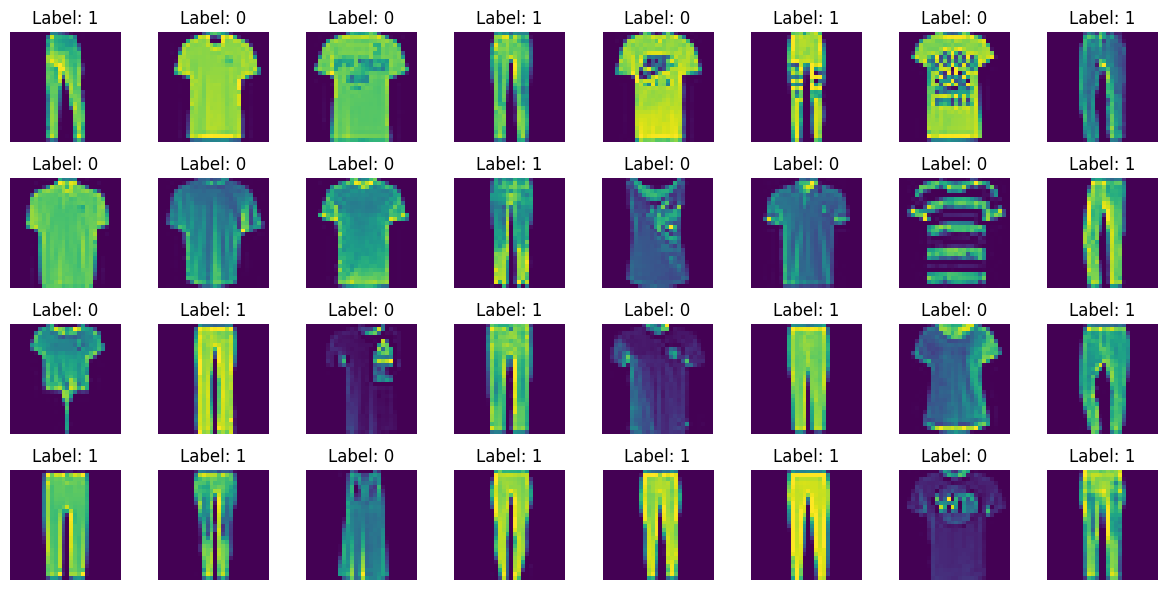

In [6]:
# Function to visualize data
def imshow(img, ax):
    img = img
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Visualize the data with labels
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()
for i in range(32):  # Display first 32 images
    img, label = images[i], labels[i].item()
    ax = axes[i]
    imshow(img, ax)
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# GAN Model

## Generator

### Generator Architecture

In [7]:
class Generator(nn.Module):
    def __init__(self, ngpu, noise_dim, label_dim, image_size):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.label_emb = nn.Embedding(label_dim, label_dim)
        self.init_size = image_size // 4
        self.generator = nn.Sequential(
            nn.Linear(noise_dim + label_dim, 128),
            nn.Linear(128, 256),
            nn.Linear(256, 512),
            nn.Linear(512, image_size * image_size),
        )
        self.output = nn.Tanh()

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        input_combined = torch.cat((noise, label_input), -1)
        out = self.generator(input_combined)
        out = self.output(out)
        out = out.view(out.size(0), 1, image_size, image_size)
        return out

### Initialize Generator

In [8]:
noise_dim = 100
label_dim = 2

In [9]:
# Create the generator
generator = Generator(ngpu, noise_dim, label_dim, image_size).to(DEVICE)

# Handle multi-GPU if desired
if (DEVICE.type == 'cuda') and (ngpu > 1):
    generator = nn.DataParallel(generator, list(range(ngpu)))

# Print the model
print(generator)

Generator(
  (label_emb): Embedding(2, 2)
  (generator): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=784, bias=True)
  )
  (output): Tanh()
)


## Discriminator

### Discriminator Architecture

In [10]:
class Discriminator(nn.Module) :
    def __init__(self, ngpu, label_dim, image_size) :
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.label_emb = nn.Embedding(label_dim, label_dim)
        self.discriminator = nn.Sequential(
            nn.Linear(image_size * image_size + label_dim, 512),
            nn.Linear(512, 1024),
            nn.Linear(1024, 1024),
            nn.Linear(1024, 512),
        )
        self.output = nn.Linear(512, 1)
        
    def forward(self, image, labels) :
        label_input = self.label_emb(labels)
        img_flat = image.view(image.size(0), -1)
        input_combined = torch.cat((img_flat, label_input), -1)
        out = self.discriminator(input_combined)
        out = F.sigmoid(self.output(out))
        return out

### Initialize Discriminator

In [11]:
# Create the Discriminator
discriminator = Discriminator(ngpu, label_dim, image_size).to(DEVICE)

# Handle multi-GPU if desired
if (DEVICE.type == 'cuda') and (ngpu > 1):
    discriminator = nn.DataParallel(discriminator, list(range(ngpu)))

# Print the model
print(discriminator)

Discriminator(
  (label_emb): Embedding(2, 2)
  (discriminator): Sequential(
    (0): Linear(in_features=786, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=1024, bias=True)
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): Linear(in_features=1024, out_features=512, bias=True)
  )
  (output): Linear(in_features=512, out_features=1, bias=True)
)


## Loss Function and Optimizer

In [12]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))

discriminator.to(DEVICE)
generator.to(DEVICE)
criterion.to(DEVICE)

BCELoss()

# Train Model

In [13]:
# For storing losses
G_losses = []
D_losses = []

# store generated image progression
generated_imgs=[]

# Training loop
for epoch in range(epochs):
    for i, (real_images, real_labels) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images, real_labels = real_images.to(DEVICE), real_labels.to(DEVICE)

        # Create labels
        real_targets = torch.ones(batch_size, 1).to(DEVICE)
        fake_targets = torch.zeros(batch_size, 1).to(DEVICE)

        # Train Discriminator
        optimizerD.zero_grad()

        # Compute BCELoss using real images
        outputs = discriminator(real_images, real_labels)
        d_loss_real = criterion(outputs, real_targets)
        d_loss_real.backward()

        # Generate fake images
        noise = torch.randn(batch_size, noise_dim).to(DEVICE)
        fake_labels = torch.randint(0, label_dim, (batch_size,)).to(DEVICE)
        fake_images = generator(noise, fake_labels)
        
        # Store generated images progressively per epoch
        if i == 0:
            generated_imgs.append(fake_images)
        
        # Compute BCELoss using fake images
        outputs = discriminator(fake_images.detach(), fake_labels)
        d_loss_fake = criterion(outputs, fake_targets)
        d_loss_fake.backward()

        # Update discriminator
        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()

        # Compute loss with fake images and flipped labels
        outputs = discriminator(fake_images, fake_labels)
        g_loss = criterion(outputs, real_targets)
        g_loss.backward()

        # Update generator
        optimizerG.step()

        # Store losses
        D_losses.append(d_loss_real.item() + d_loss_fake.item())
        G_losses.append(g_loss.item())

    print(f'Epoch [{epoch+1}/{epochs}], d_loss: {d_loss_real.item() + d_loss_fake.item():.4f}, g_loss: {g_loss.item():.4f}')

# Save losses for plotting
torch.save({'G_losses': G_losses, 'D_losses': D_losses}, 'losses.pth')

Epoch [1/10], d_loss: 1.0354, g_loss: 3.0729
Epoch [2/10], d_loss: 0.9897, g_loss: 2.0636
Epoch [3/10], d_loss: 1.0926, g_loss: 2.7005
Epoch [4/10], d_loss: 1.0742, g_loss: 1.3247
Epoch [5/10], d_loss: 1.9353, g_loss: 1.8535
Epoch [6/10], d_loss: 1.4272, g_loss: 2.8135
Epoch [7/10], d_loss: 1.0109, g_loss: 2.0703
Epoch [8/10], d_loss: 1.6096, g_loss: 1.1293
Epoch [9/10], d_loss: 1.3881, g_loss: 1.0048
Epoch [10/10], d_loss: 1.2738, g_loss: 1.0077


# Evaluate Model

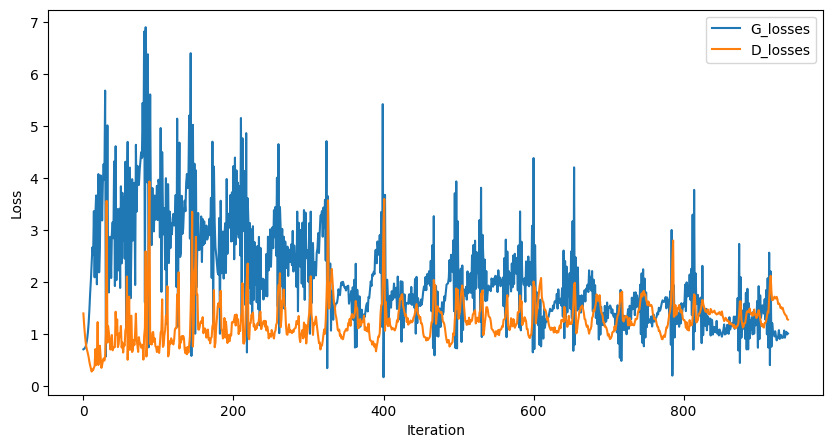

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='G_losses')
plt.plot(D_losses, label='D_losses')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

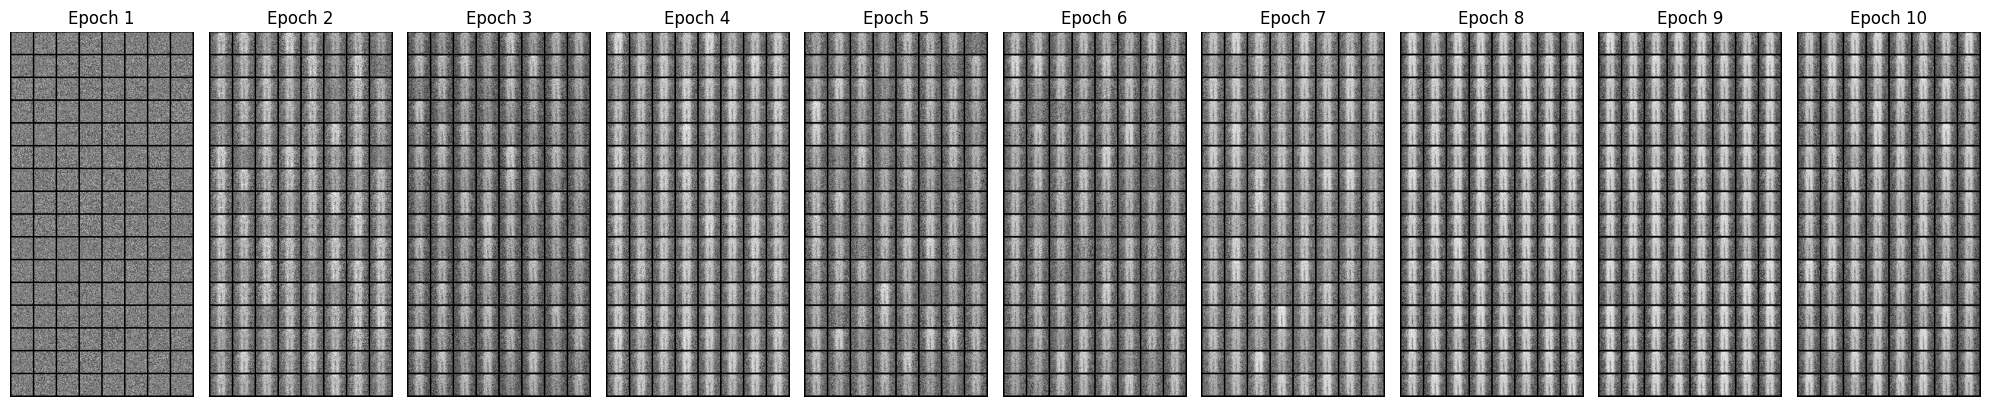

In [15]:
# Show generated images per epoch
fig, axes = plt.subplots(1, len(generated_imgs), figsize=(20, 10))
for i, images in enumerate(generated_imgs):
    axes[i].imshow(vutils.make_grid(images, padding=2, normalize=True).cpu().detach().numpy().transpose((1, 2, 0)))
    axes[i].axis('off')
    axes[i].set_title(f'Epoch {i+1}')
    
plt.tight_layout()
plt.show()

## Generate New Images

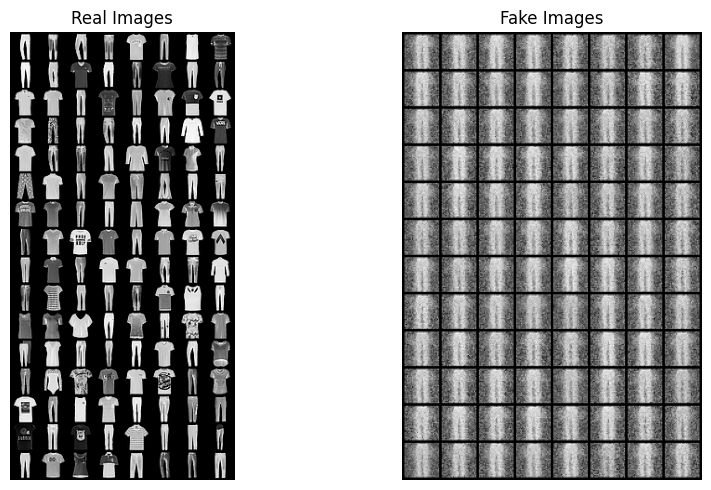

In [28]:
# Generate images with the trained generator with the same amount of real images from the test set

# Get a batch of real images
dataiter = iter(test_loader)
real_images, real_labels = next(dataiter)

# Generate fake images
noise = torch.randn(batch_size, noise_dim).to(DEVICE)
fake_labels = torch.randint(0, label_dim, (batch_size,)).to(DEVICE)

with torch.no_grad():
    fake_images = generator(noise, fake_labels)
    
# Visualize the real images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(vutils.make_grid(real_images, padding=2, normalize=True).cpu().detach().numpy().transpose((1, 2, 0)))
axes[0].axis('off')
axes[0].set_title('Real Images')

# Visualize the fake images
axes[1].imshow(vutils.make_grid(fake_images, padding=2, normalize=True).cpu().detach().numpy().transpose((1, 2, 0)))
axes[1].axis('off')
axes[1].set_title('Fake Images')

plt.tight_layout()
plt.show()

In [29]:
## Save Real and Fake Images to directory separated by labels
import os
import torchvision.utils as vutils

# Create directories
os.makedirs('real_images', exist_ok=True)
os.makedirs('fake_images', exist_ok=True)

# Save real images
for i, image in enumerate(real_images):
    vutils.save_image(image, f'real_images/real_image_{i}.png')
    
# Save fake images
for i, image in enumerate(fake_images):
    vutils.save_image(image, f'fake_images/fake_image_{i}.png')
    
# Save the models
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

In [32]:
# Compute the Frechet Inception Distance (FID) to evaluate the quality of the generated images using pytorch-fid
import pytorch_fid.fid_score as fid_score

fid_score.calculate_fid_given_paths(['real_images', 'fake_images'], batch_size, DEVICE, 2048)

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\kanek/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [01:48<00:00, 878kB/s] 
100%|██████████| 1/1 [00:10<00:00, 10.63s/it]


308.46554800046033

Dari score FID menandakan ada banyak disturbance dalam predicted images